## Importing Libraries

All the relevant libraries have been import below. You cannot make any new imports. Do NOT modify the cell below.

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split, Subset
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm
from sklearn.metrics import (
    accuracy_score, f1_score, recall_score,
    confusion_matrix, roc_curve, auc, classification_report
)
import random
import seaborn as sns
from PIL import Image

np.random.seed(42)

In [2]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# DEVICE = torch.device("mps" if torch.backends.mps.is_available() else "cpu") # For MAC users (comment this out if you are running this locally)

## 1) Download the MNIST Dataset

- Download the dataset using `torchvision`
- Apply any necessary transforms
- Print the size of the train and test split

In [3]:
transform = transforms.ToTensor()
traindset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
testdset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)
print(len(traindset))
print(len(testdset))

60000
10000


## 2) Create Train, Test, Val Splits 

- Split the dataset using the `random_split` function
- You should have the following split:
    - Train: 50,000 samples
    - Test: 10,000 samples
    - Validation: 10,000 samples
- Load the dataset into `DataLoaders`
- Print the size of each split

In [4]:
traindataset, valdset = random_split(traindset, [50000, 10000], generator=torch.Generator().manual_seed(42))
train_loader = DataLoader(traindataset, batch_size=32, shuffle=True)
val_loader = DataLoader(valdset, batch_size=32)
test_loader = DataLoader(testdset, batch_size=32)
print(len(train_loader.dataset))
print(len(val_loader.dataset))
print(len(test_loader.dataset))

50000
10000
10000


## 3) Visualisation

- Write a function `visualise_samples` that visualises a random sample with its label
- It should take 2 arguments
    - `dataloader`
    - `num_samples`
- Make sure to call the function to generate two samples

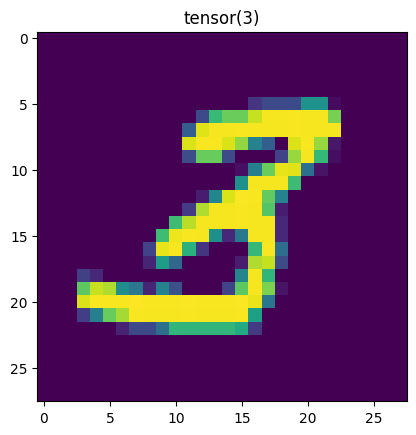

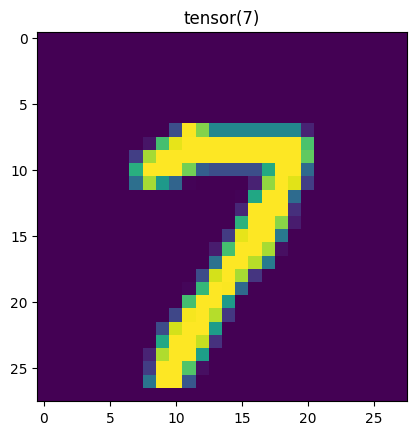

In [5]:
def visualise_samples(dataloader, num_samples):
    dataiter = iter(dataloader)
    images, labels = next(dataiter)
    num_samples = min(num_samples, images.size(0))
    rand = np.random.choice(len(images), num_samples, replace=False)
    for i in rand:
        image = images[i].squeeze(0)
        label = labels[i]
        plt.imshow(image)
        plt.title(label)
        plt.show()

visualise_samples(train_loader,2)

## 4) Forward Pass in Numpy

**4.1) He initialization** 

He initialization is used to set the initial weights of neural network layers, especially those with ReLU activations. It helps maintain the variance of activations throughout the network, which improves training stability and convergence.

The formula for He initialization is:
$$
W_{ij} \sim \mathcal{N}\left(0, \frac{2}{\text{in\_dim}}\right)
$$
where $$\text{in\_dim}$$ is the number of input units to the layer. In simple terms, it means the weight matrix is initialised by sampling from a normal distribution with 0 mean and $\frac{2}{\text{in\_dim}}$ variance.

**Write a function, `he_init` function takes two arguments as input:**
- `in_dim`: The number of input units to the layer.
- `out_dim`: The number of output units (neurons) in the layer.

It returns:
- `W`: A weight matrix of shape `(out_dim, in_dim)` initialized using the He initialization method.
- `b`: A bias vector of shape `(out_dim, 1)` initialized to zeros.




In [6]:
def he_init(in_dim, out_dim):
    std = np.sqrt(2 / in_dim)
    weights = np.random.normal(0, std, (out_dim, in_dim))
    bias = np.zeros((out_dim, 1))
    return weights, bias

**4.2) Weight Initialization** 
- Your network should have the following architecture:
    - Input layer: 28x28 (flattened MNIST image)
    - Hidden layer 1: 256 units, ReLU activation
    - Hidden layer 2: 128 units, ReLU activation
    - Output layer: 10 units, softmax activation
- Initialise all the matrices (weights, and biases) using he_init with the correct dimensions.

In [7]:
# Layer 1
l1w, l1b = he_init(28 * 28, 256)
# Layer 2
l2w, l2b = he_init(256, 128)
# Layer 3
l3w, l3b = he_init(128, 10)

**4.3) Activations** 
- Write a function for ReLU
- Write a function for Softmax

In [8]:
# Relu
def ReLU(z):
    return np.where(z > 0, z , 0)

In [9]:
# Softmax
def Softmax(z):
    return np.exp(z) / np.sum(np.exp(z), axis=0)

**4.4) Forward Pass** 
- Now that you have your weights initialized, perform a forward pass on an image from the test set of  MNIST.
- Print the output probabilities and the predicted class

In [10]:
dataiter = iter(test_loader)
image, label = next(dataiter)
image = image[0].numpy()
label = label[0].item()
x = image.flatten().reshape(28 * 28, 1)
z1 = np.dot(l1w, x) + l1b
a1 = ReLU(z1)
z2 = np.dot(l2w, a1) +l2b
a2 = ReLU(z2)
z3 = np.dot(l3w, a2) + l3b
a3 = Softmax(z3)
out = np.argmax(a3)
print(a3)
print(out)

[[0.05099667]
 [0.1156842 ]
 [0.18692692]
 [0.07943564]
 [0.07349601]
 [0.09708512]
 [0.1010056 ]
 [0.13824408]
 [0.09140885]
 [0.0657169 ]]
2


# 5) Implement the Backward Pass

In this exercise, you will implement **backpropagation** for a lightweight fully connected neural network using only **NumPy**.   The goal is to compute gradients of weights and biases for each layer using the **chain rule** of calculus.  
Note: caches are not required for this implementation

In [11]:
# ---- Activation derivatives (TO BE IMPLEMENTED) ----
def dsigmoid(a):
    return a * (1 - a)

def dtanh(a):
    return 1 - (a ** 2)

def drelu(z):
    return np.where(z > 0, 1, 0)

# ---- Backward Pass (TO BE IMPLEMENTED) ----
def backward(W, b, A, Z, Y, activations):
    """
    Compute gradients for a fully-connected MLP (no caches passed around).
    Inputs:
        W, b  : lists of weights/biases, indexed 1..L
        A, Z  : lists of activations and pre-activations, A[0]=X^T, up to A[L]
        Y     : (m,1) labels
        activations: list of names per layer, e.g. [None, 'tanh', 'sigmoid']
    Returns:
        dW, db: lists of gradients, indexed 1..L
    """
    Y = Y.T
    Layers = len(W) - 1
    m = Y.shape[1]
    dZ = [None for i in range(Layers + 1)]
    dW = [None for i in range(Layers + 1)]
    db = [None for i in range(Layers + 1)]
    for i in range(Layers, 0, -1):
        if i == Layers:
            dZ[i] = A[i] - Y
        else:
            if activations[i] == "tanh":
                dZ[i] = np.dot(W[i + 1].T, dZ[i + 1]) * dtanh(Z[i])
            elif activations[i] == "sigmoid":
                dZ[i] = np.dot(W[i + 1].T, dZ[i + 1]) * dsigmoid(Z[i])
            elif activations[i] == "relu":
                dZ[i] = np.dot(W[i + 1].T, dZ[i + 1]) * drelu(Z[i])
        dW[i] = (1/m) * np.dot(dZ[i], A[i-1].T)
        db[i] = (1/m) * np.sum(dZ[i], axis=1, keepdims=True)
    return dW, db


**Backprop Testing (Just run the code block below without changing anything)**

In [12]:
np.random.seed(0)
m = 4
X = np.random.randn(m,2)
Y = (np.random.rand(m,1) > 0.5).astype(int)

W = [None, np.random.randn(3,2)*0.1, np.random.randn(1,3)*0.1]
b = [None, np.zeros((3,1)), np.zeros((1,1))]
Z = [None,
     np.random.randn(3,m),
     np.random.randn(1,m)]
A = [X.T,
     np.tanh(Z[1]),
     1/(1+np.exp(-Z[2]))]

activations = [None, "tanh", "sigmoid"]

dW, db = backward(W, b, A, Z, Y, activations)

print("dW[1] shape:", None if dW[1] is None else dW[1].shape)
print("db[1] shape:", None if db[1] is None else db[1].shape)
print("dW[2] shape:", None if dW[2] is None else dW[2].shape)
print("db[2] shape:", None if db[2] is None else db[2].shape)

dW[1] shape: (3, 2)
db[1] shape: (3, 1)
dW[2] shape: (1, 3)
db[2] shape: (1, 1)


## 6) Neural Networks In PyTorch 

**6.1) Helper Function** 

- Create a function `count_parameters` that takes in a model and returns its parameter count.

In [13]:
def count_parameters(model):
    count = 0
    for i in model.parameters():
        count += i.numel()
    return count

**6.2) Fully-Connected Neural Network (FCNN) for Digit Classification in PyTorch** 
- Create a FCNN utilising ReLU activations with more than 200,000 parameters. Print its parameter count.
- Note: You are NOT allowed to use convolutions.

In [14]:
class FCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten() 
        self.l1 = nn.Linear(28 * 28, 256)
        self.l2 = nn.Linear(256, 128)
        self.l3 = nn.Linear(128, 10)

    def forward(self, x, softmax=False):
        x = self.flatten(x)
        x = F.relu(self.l1(x))
        x = F.relu(self.l2(x))
        if softmax:
            x = F.softmax(self.l3(x), dim=1)
        else:
            x = self.l3(x)
        return x
    
model1 = FCNN()
parameters = count_parameters(model1)
print(parameters)

235146


**6.3) Hyperparameters** 
- Define the criterion, optimizer, and learning rate
- Do NOT change the number of epochs
- In a markdown cell, explain the choice of your criterion (loss function)

In [15]:
EPOCHS = 10
LR = 0.001
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model1.parameters(), LR)

Ans: I put an option in the forward to enable softmax or not, so i can use cross entropy loss on raw logits. Cross entropy loss computers softmax internally and works with multiclass predictions.

**6.4) Training and Evaluation Functions** 
- Write a function `train` that takes in the model, dataloader, optimizer, and criterion, and trains the model for one epoch. It should return the average loss and accuracy for that epoch.
- Write a function `evaluate` that takes in the model, dataloader, and criterion, and evaluates the model on the validation or test set. It should return the average loss and accuracy.
- In a markdown cell below, also explain the use of the following functions:
    -  `optimizer.zero_grad()`
    -  `loss.backward()`
    -  `optimizer.step()`

In [16]:
# train function below
def train(model, dataloader, optimizer, criterion):
    model.train()
    losses = []
    correct = 0
    total = 0
    for images, labels in dataloader:
        optimizer.zero_grad()
        preds = model(images)
        loss = criterion(preds, labels)
        losses.append(loss.item())
        loss.backward()
        optimizer.step()
        pred_labels = preds.argmax(dim=1)
        correct += (pred_labels == labels).sum().item()
        total += labels.size(0)
    avgL = sum(losses) / len(losses)
    return avgL, correct/total

In [17]:
# evaluate function below
def evaluate(model, dataloader, criterion):
    model.eval()
    losses = []
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in dataloader:
            preds = model(images)
            loss = criterion(preds, labels)
            losses.append(loss.item())
            pred_labels = preds.argmax(dim=1)
            correct += (pred_labels == labels).sum().item()
            total += labels.size(0)
    avgL = sum(losses) / len(losses)
    return avgL, correct/total

Ans: We use optimiser.zero_grad() to clear out the old gradients so it dosnt mess up the current ones we want to compute. loss.backward() is used to propogate the loss to all the layers computing esentially dW(s) and db(s) for each layer. optimiser.step() is the part where we update the actual weights using the gradients from loss.backward() using the optimiser we chose.

**6.5) Training Loop** 
- Write a loop to train your model for the specified number of epochs.
- For each epoch, print the training loss, training accuracy, validation loss, and validation accuracy.
- Use your `train` and `evaluate` functions to get these values for each epoch.
- Save the model with the best validation accuracy.
- Plot the loss and accuracy curves (for both train and val set).
- Make sure to label the graphs correctly.

Epoch:  1 Train loss: 0.25803291486899155 Train accuracy:  0.92322 Validation loss:  0.16031478426624507 Validation accuracy:  0.954
Epoch:  2 Train loss: 0.10272273007242255 Train accuracy:  0.968 Validation loss:  0.10612716405881575 Validation accuracy:  0.9674
Epoch:  3 Train loss: 0.06474492281816259 Train accuracy:  0.97938 Validation loss:  0.09729456935526458 Validation accuracy:  0.9731
Epoch:  4 Train loss: 0.050734850334500585 Train accuracy:  0.9837 Validation loss:  0.099609568988281 Validation accuracy:  0.9714
Epoch:  5 Train loss: 0.03959237374574624 Train accuracy:  0.98714 Validation loss:  0.10435695010649312 Validation accuracy:  0.9713
Epoch:  6 Train loss: 0.030846897280409284 Train accuracy:  0.9902 Validation loss:  0.08503740205852198 Validation accuracy:  0.9767
Epoch:  7 Train loss: 0.026180536248553925 Train accuracy:  0.99128 Validation loss:  0.09769850756317308 Validation accuracy:  0.9761
Epoch:  8 Train loss: 0.01914325398896869 Train accuracy:  0.99356

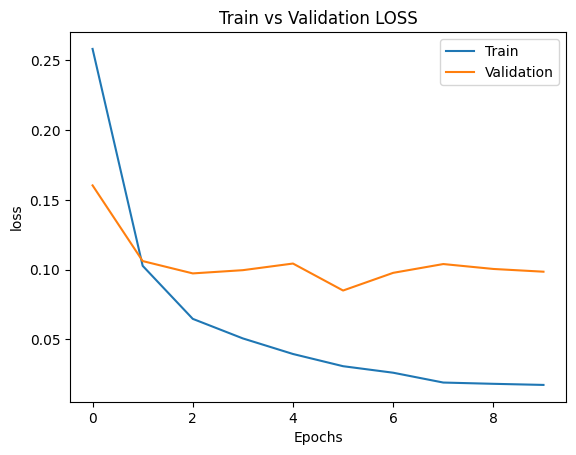

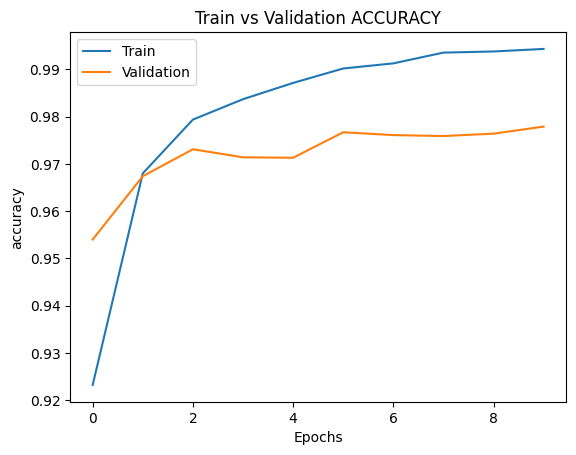

In [18]:
best_acc = 0
trainL = []
valL = []
train_acc = []
val_acc = []
for i in range(EPOCHS):
    tL, tA = train(model1, train_loader, optimizer, criterion)
    vL, vA = evaluate(model1, val_loader, criterion)
    trainL.append(tL)
    valL.append(vL)
    train_acc.append(tA)
    val_acc.append(vA)
    if vA > best_acc:
        best_acc = vA
        torch.save(model1.state_dict(), 'best_model.pth')
    print("Epoch: ", i + 1, "Train loss:", tL, "Train accuracy: ", tA, "Validation loss: ", vL,"Validation accuracy: ", vA)
plt.figure()
plt.plot(trainL, label="Train")
plt.plot(valL, label="Validation")
plt.title("Train vs Validation LOSS")
plt.xlabel("Epochs")
plt.ylabel("loss")
plt.legend()
plt.show()
plt.figure()
plt.plot(train_acc, label="Train")
plt.plot(val_acc, label="Validation")
plt.title("Train vs Validation ACCURACY")
plt.xlabel("Epochs")
plt.ylabel("accuracy")
plt.legend()
plt.show()

**6.6) Evaluation** 
- Load the model with the best validation accuracy.
- Evaluate this model on the test set and report the following:
    - Accuracy **(should be higher than 95%)**
    - F1 (macro) **(should be higher than 95%)**
    - Recall (macro) **(should be higher than 95%)**
- Print the classification report.
- Visualise the confusion matrix.
- Plot the ROC curve.
- Write a function `visualise_incorrect` that visualises the incorrectly labelled samples with their true and predicted labels.

In [35]:
# Load the best model below
W_model = FCNN()
W_model.load_state_dict(torch.load("best_model.pth"))
W_model.eval()
W_preds = []
W_labels = []
W_probs = []
with torch.no_grad():
    for images, labels in test_loader:
        preds = W_model(images)
        probs = torch.softmax(preds, dim=1)
        pred_labels = preds.argmax(dim=1)
        W_preds.extend(pred_labels.numpy())
        W_labels.extend(labels.numpy())
        W_probs.extend(probs.numpy()) 
W_preds = np.array(W_preds)
W_labels = np.array(W_labels)
W_probs = np.array(W_probs)

In [36]:
# Show required evaluation metrics below
W_acc = accuracy_score(W_labels, W_preds)
W_f1 = f1_score(W_labels, W_preds, average="macro")
W_recall = recall_score(W_labels, W_preds, average="macro")
W_cm = confusion_matrix(W_labels, W_preds)
print(W_acc)
print(W_f1)
print(W_recall)
print(classification_report(W_labels, W_preds))

0.9799
0.979743667727905
0.9797926698836689
              precision    recall  f1-score   support

           0       0.98      0.99      0.98       980
           1       0.99      0.99      0.99      1135
           2       0.98      0.98      0.98      1032
           3       0.98      0.98      0.98      1010
           4       0.99      0.97      0.98       982
           5       0.97      0.98      0.98       892
           6       0.98      0.99      0.98       958
           7       0.99      0.97      0.98      1028
           8       0.98      0.97      0.98       974
           9       0.97      0.98      0.97      1009

    accuracy                           0.98     10000
   macro avg       0.98      0.98      0.98     10000
weighted avg       0.98      0.98      0.98     10000



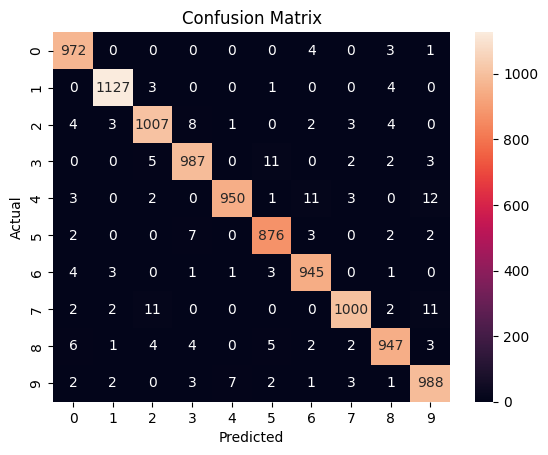

In [37]:
# Plot confusion matrix below
plt.figure()
sns.heatmap(W_cm, annot=True, fmt='d')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

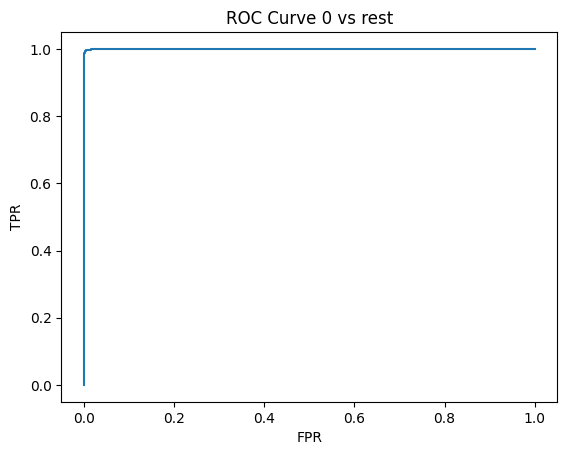

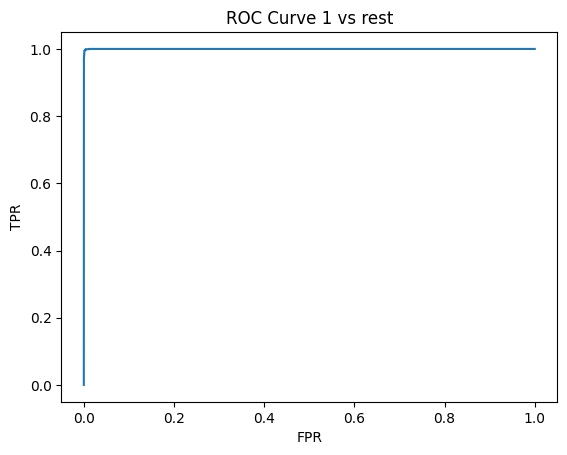

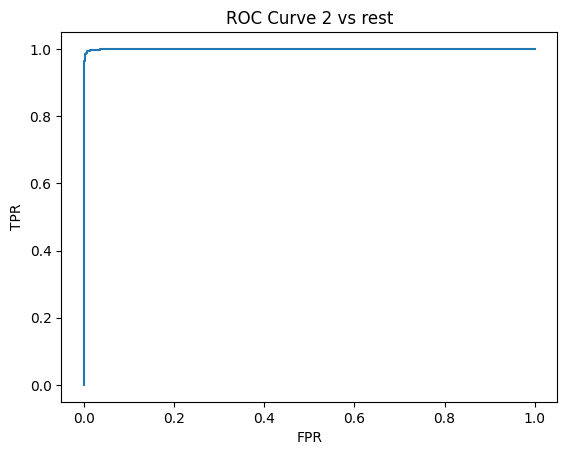

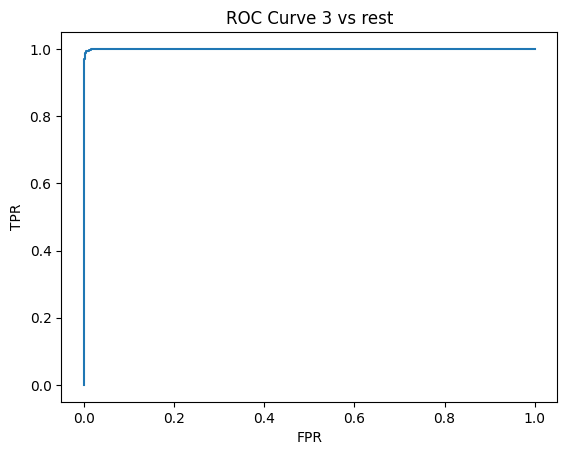

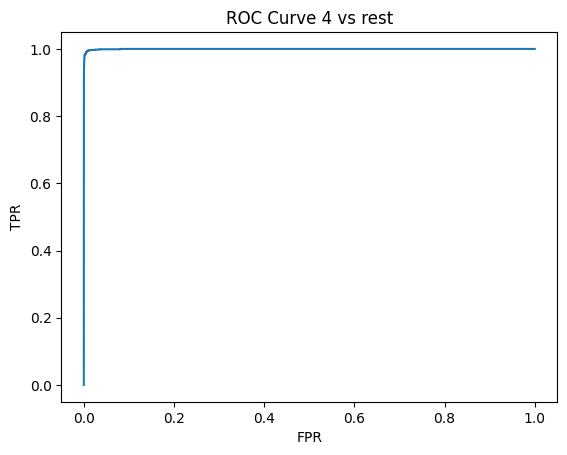

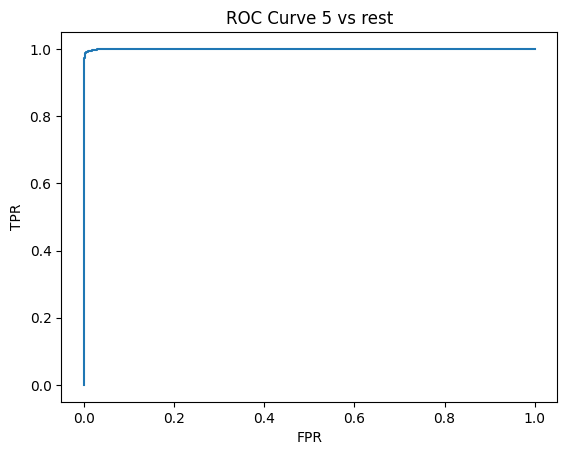

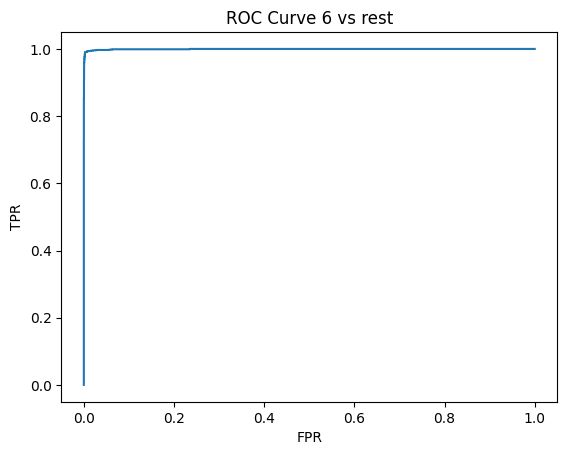

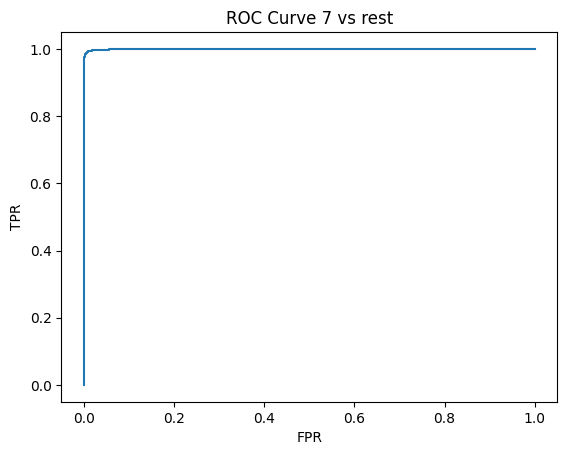

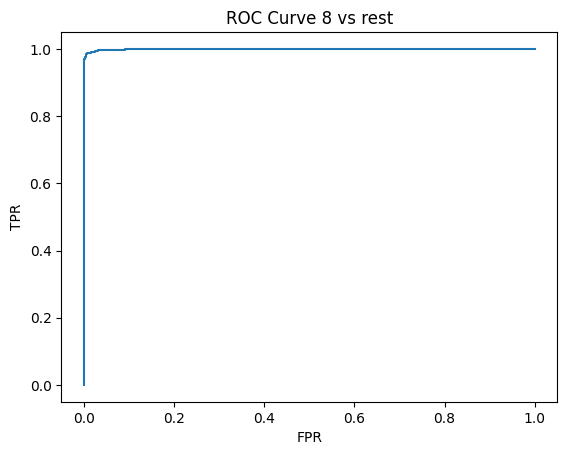

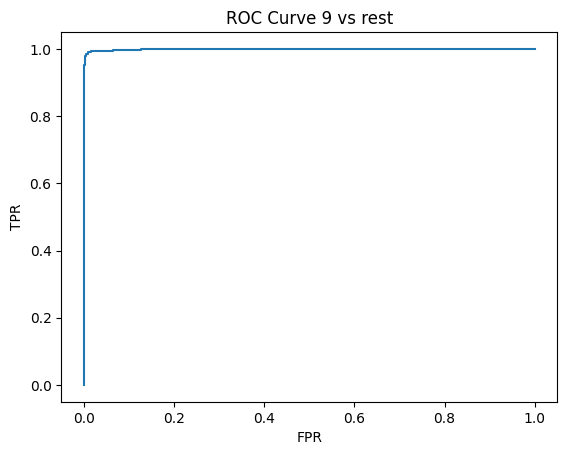

In [38]:
# Plot ROC curve below
classes = np.unique(W_labels)
for i in classes:
    onehot = (W_labels == i).astype(int)
    class_probs = W_probs[:, i]
    fpr, tpr, abc = roc_curve(onehot, class_probs)
    roc = auc(fpr, tpr)
    plt.figure()
    plt.plot(fpr, tpr)
    plt.xlabel("FPR")
    plt.ylabel("TPR")
    plt.title(f"ROC Curve {i} vs rest")
    plt.show()


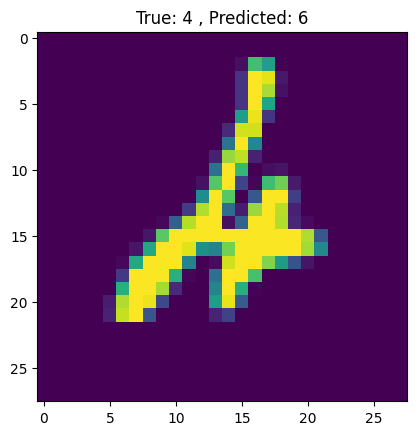

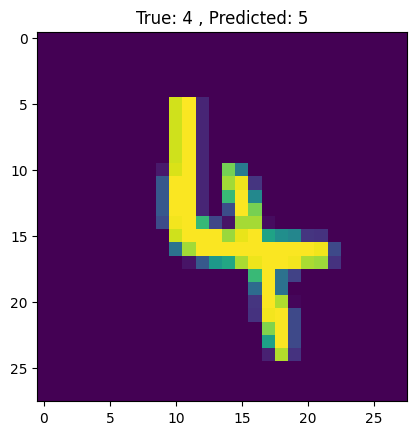

In [39]:
# Write visualise function below and make sure to visalize some atleast two samples
def visualise_incorrect(model, dataloader, num_samples):
    model.eval()
    incorrect_images = []
    incorrect_labels = []
    incorrect_preds = []
    with torch.no_grad():
        for images, labels in dataloader:
            preds = model(images)
            pred_labels = preds.argmax(dim=1)
            mask = (pred_labels != labels)
            for i in range(len(pred_labels)):
                if mask[i]:
                    incorrect_images.append(images[i])
                    incorrect_labels.append(labels[i].item())
                    incorrect_preds.append(pred_labels[i].item())
                if len(incorrect_images) >= num_samples:
                    break
            if len(incorrect_images) >= num_samples:
                break
    for i in range(num_samples):
        image = incorrect_images[i].squeeze(0)
        label_t = incorrect_labels[i]
        label_p = incorrect_preds[i]
        plt.imshow(image)
        plt.title(f"True: {label_t} , Predicted: {label_p}")
        plt.show()

visualise_incorrect(W_model, test_loader, 2)

**6.7) Out-of-distribution (OOD) Evaluation** 
- Write any digit on a piece of paper and take a photo of it.
- Load the photo and apply any processing necessary to get the image ready to be passed into the FCNN.
- Visualise the image.
- Run inference on the image and print all the output probabilities and its predicted class.
- Comment on whether the model is able to correctly predict the digit? Why or why not? 

[[5.9365481e-02 2.3910073e-03 6.4680382e-05 1.0784518e-01 2.6817350e-08
  8.2385468e-01 1.3934377e-03 5.0846059e-03 8.0705649e-07 1.2617554e-07]]
5


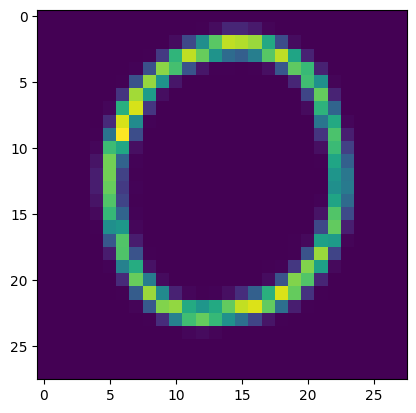

In [42]:
from PIL import ImageOps
img = Image.open("0.png").convert('L')
img = ImageOps.invert(img)
transform = transforms.Compose([transforms.Resize((28,28)), transforms.ToTensor()])
processed = transform(img)
plt.imshow(processed.squeeze())
W_model.eval()
with torch.no_grad():
    pred = W_model(processed.view(1, -1))
    prob = F.softmax(pred, dim=1)
    pred_label = prob.argmax(dim=1).item()
print(prob.numpy())
print(pred_label)
# I think it got it wrong becasuse the model was trained on MINST dataset which used black background and white writing where as what i have is white paper and black pen. Also looks to me like my writing should have been thicker. Many small thing that arent standadized in my image can cause this as well.